c:\Users\muham\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\muham\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\muham\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\muham\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


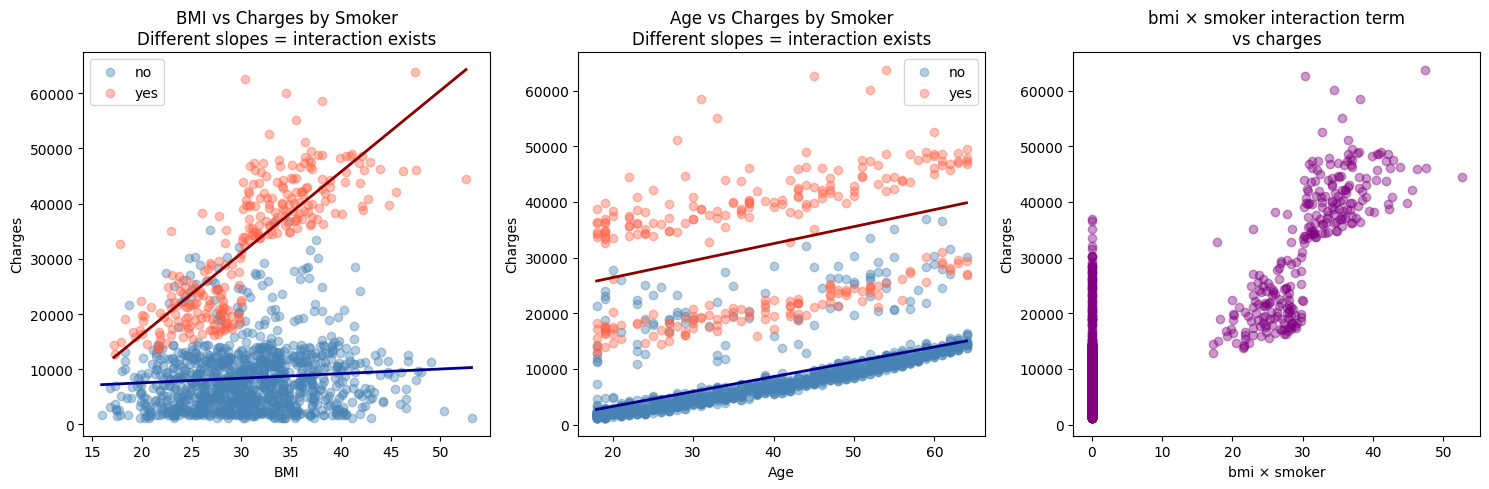

Correlation with charges:
  bmi alone          : 0.1983
  smoker alone       : 0.7873
  bmi × smoker       : 0.8451

Cross-validated R²:
  Without interactions : 0.7469
  With interactions    : 0.8359
  Improvement          : 0.0889

  → Interactions add real value — keep them


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

# ── Load your data ─────────────────────────────────────────────────
df = pd.read_csv('./dataset/insurance.csv')
df['smoker_enc'] = (df['smoker'] == 'yes').astype(int)

# ── VISUAL CHECK 1 ─────────────────────────────────────────────────
# Plot bmi vs charges, split by smoker
# If the slopes are different → interaction exists
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# bmi × smoker
for status, grp in df.groupby('smoker'):
    axes[0].scatter(grp['bmi'], grp['charges'],
                    alpha=0.4, label=status,
                    color='tomato' if status=='yes' else 'steelblue')
    # fit a line per group
    m = LinearRegression().fit(grp[['bmi']], grp['charges'])
    x_range = np.linspace(grp['bmi'].min(), grp['bmi'].max(), 50)
    axes[0].plot(x_range, m.predict(x_range.reshape(-1,1)),
                 linewidth=2,
                 color='darkred' if status=='yes' else 'darkblue')

axes[0].set_title('BMI vs Charges by Smoker\nDifferent slopes = interaction exists')
axes[0].set_xlabel('BMI'); axes[0].set_ylabel('Charges')
axes[0].legend()

# age × smoker
for status, grp in df.groupby('smoker'):
    axes[1].scatter(grp['age'], grp['charges'],
                    alpha=0.4, label=status,
                    color='tomato' if status=='yes' else 'steelblue')
    m = LinearRegression().fit(grp[['age']], grp['charges'])
    x_range = np.linspace(grp['age'].min(), grp['age'].max(), 50)
    axes[1].plot(x_range, m.predict(x_range.reshape(-1,1)),
                 linewidth=2,
                 color='darkred' if status=='yes' else 'darkblue')

axes[1].set_title('Age vs Charges by Smoker\nDifferent slopes = interaction exists')
axes[1].set_xlabel('Age'); axes[1].set_ylabel('Charges')
axes[1].legend()

# bmi × smoker — directly show the interaction term effect
df['bmi_x_smoker'] = df['bmi'] * df['smoker_enc']
axes[2].scatter(df['bmi_x_smoker'], df['charges'],
                alpha=0.4, color='purple')
axes[2].set_title('bmi × smoker interaction term\nvs charges')
axes[2].set_xlabel('bmi × smoker'); axes[2].set_ylabel('Charges')

plt.tight_layout()
plt.show()


# ── VISUAL CHECK 2 ─────────────────────────────────────────────────
# Correlation of interaction term with target
print("Correlation with charges:")
print(f"  bmi alone          : {df['bmi'].corr(df['charges']):.4f}")
print(f"  smoker alone       : {df['smoker_enc'].corr(df['charges']):.4f}")
print(f"  bmi × smoker       : {df['bmi_x_smoker'].corr(df['charges']):.4f}")
# If bmi×smoker has HIGHER correlation than bmi alone → interaction adds value


# ── NUMERIC CHECK — compare R² with and without interaction ────────
from sklearn.model_selection import cross_val_score

df['age_x_smoker'] = df['age'] * df['smoker_enc']

features_without = ['age', 'bmi', 'children', 'smoker_enc']
features_with    = ['age', 'bmi', 'children', 'smoker_enc',
                    'bmi_x_smoker', 'age_x_smoker']

X_without = df[features_without]
X_with    = df[features_with]
y         = df['charges']

model = LinearRegression()

r2_without = cross_val_score(model, X_without, y,
                              cv=5, scoring='r2').mean()
r2_with    = cross_val_score(model, X_with, y,
                              cv=5, scoring='r2').mean()

print(f"\nCross-validated R²:")
print(f"  Without interactions : {r2_without:.4f}")
print(f"  With interactions    : {r2_with:.4f}")
print(f"  Improvement          : {r2_with - r2_without:.4f}")

if r2_with > r2_without + 0.01:
    print("\n  → Interactions add real value — keep them")
elif r2_with > r2_without:
    print("\n  → Marginal improvement — use only if interpretability allows")
else:
    print("\n  → Interactions add no value — remove them")

Features: ['age', 'bmi', 'children', 'smoker_enc', 'sex_enc']
Target  : charges
Shape   : (1338, 5)

══════════════════════════════════════════════════════════════
  METHOD 1 — Correlation screening
══════════════════════════════════════════════════════════════

  Interaction                    Corr w/ target    Added value
  ────────────────────────────────────────────────────────────
  bmi × smoker_enc                       0.8451         0.0579 ← candidate
  age × smoker_enc                       0.7893         0.0020 ← candidate
  smoker_enc × sex_enc                   0.5998        -0.1875 ← candidate
  children × smoker_enc                  0.5249        -0.2624 ← candidate
  age × bmi                              0.3348         0.0357 ← candidate
  age × sex_enc                          0.1490        -0.1500
  age × children                         0.1320        -0.1670
  bmi × children                         0.1026        -0.0957
  bmi × sex_enc                          0.1018

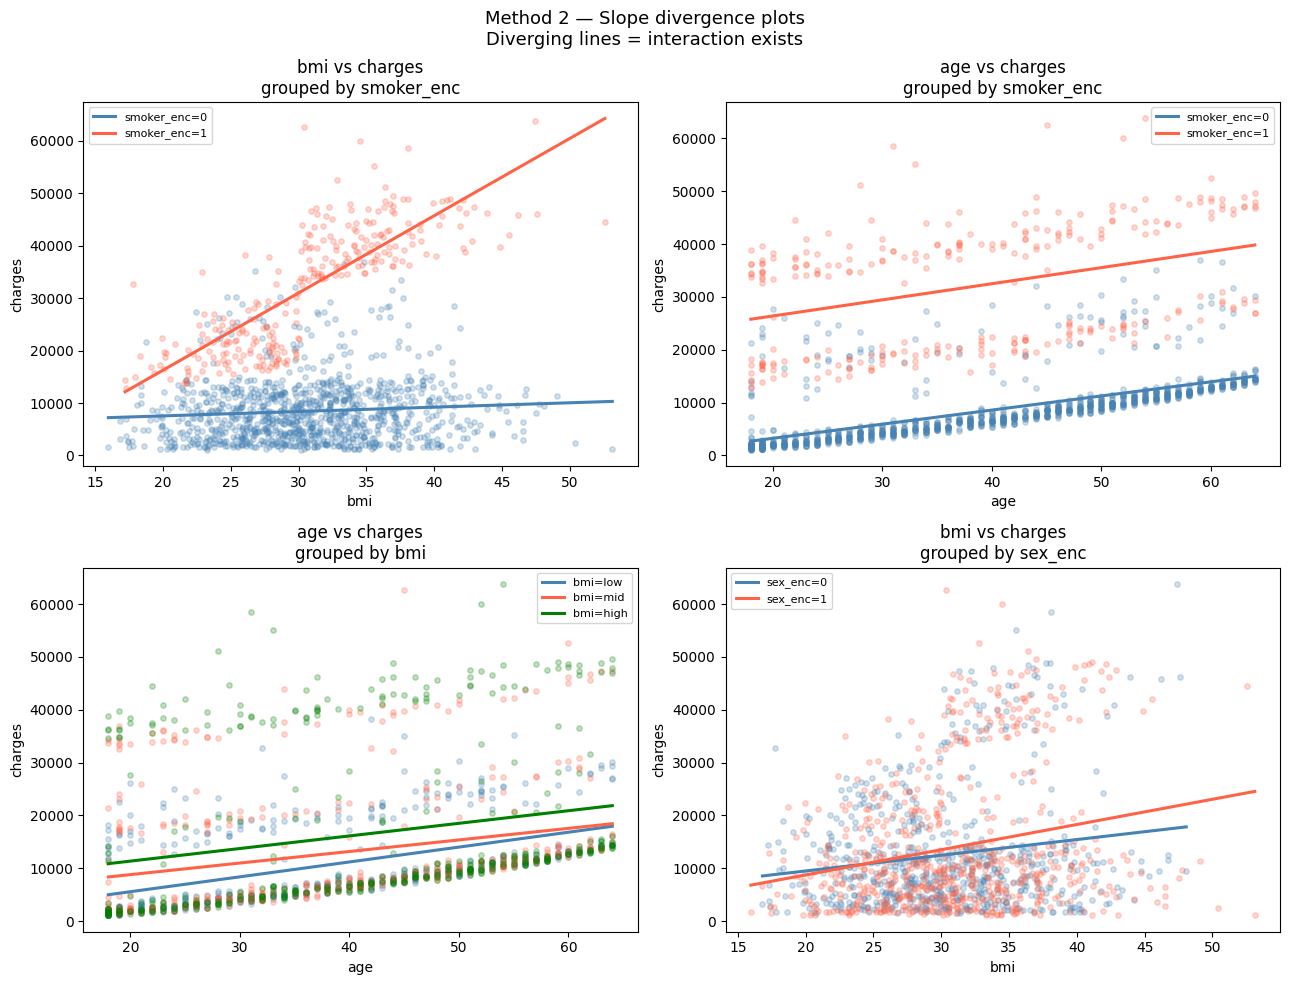

  Diverging lines = interaction is real
  Parallel lines  = no interaction needed

══════════════════════════════════════════════════════════════
  METHOD 3 — Statistical significance (p-value test)
══════════════════════════════════════════════════════════════
  Interaction                     p-value  Verdict
  ────────────────────────────────────────────────────────
  age × bmi                      0.9012  not significant
  age × children                 0.9376  not significant
  age × smoker_enc               0.1317  not significant
  age × sex_enc                  0.9065  not significant
  bmi × children                 0.1847  not significant
  bmi × smoker_enc               0.0000  SIGNIFICANT ✓ ← keep
  bmi × sex_enc                  0.9518  not significant
  children × smoker_enc               0.2327  not significant
  children × sex_enc                  0.9294  not significant
  smoker_enc × sex_enc                  0.0056  SIGNIFICANT ✓ ← keep

  Significant interactions fou

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')

# ══════════════════════════════════════════════════════════════════
# SETUP — plug in your data here
# ══════════════════════════════════════════════════════════════════

df = pd.read_csv('./dataset/insurance.csv')


# Encode categoricals to numeric for interaction search
df['smoker_enc']  = (df['smoker'] == 'yes').astype(int)
df['sex_enc']     = (df['sex'] == 'male').astype(int)

df['bmi_x_smoker_enc'] = df['bmi'] * df['smoker_enc']

# One-hot encode region
df = pd.get_dummies(df, columns=['region'], drop_first=True)

target        = 'charges'
numeric_feats = ['age', 'bmi', 'children',
                 'smoker_enc', 'sex_enc']   # features to search interactions for

X = df[numeric_feats]
y = df[target]

print("Features:", numeric_feats)
print("Target  :", target)
print("Shape   :", X.shape)


# ══════════════════════════════════════════════════════════════════
# METHOD 1 — Correlation screening
# Fastest way to shortlist candidate interactions
# ══════════════════════════════════════════════════════════════════

print("\n" + "═"*62)
print("  METHOD 1 — Correlation screening")
print("═"*62)

interaction_corrs = []

# Generate all pairs
for f1, f2 in combinations(numeric_feats, 2):
    interaction_term = X[f1] * X[f2]
    corr_with_target = interaction_term.corr(y)
    corr_f1          = X[f1].corr(y)
    corr_f2          = X[f2].corr(y)

    # Only interesting if interaction adds more than either alone
    added_value = abs(corr_with_target) - max(abs(corr_f1), abs(corr_f2))

    interaction_corrs.append({
        'interaction'     : f"{f1} × {f2}",
        'corr_with_target': round(corr_with_target, 4),
        'corr_f1_alone'   : round(corr_f1, 4),
        'corr_f2_alone'   : round(corr_f2, 4),
        'added_value'     : round(added_value, 4)
    })

corr_df = pd.DataFrame(interaction_corrs)
corr_df = corr_df.sort_values('corr_with_target',
                               key=abs, ascending=False)

print(f"\n  {'Interaction':<28} {'Corr w/ target':>16} "
      f"{'Added value':>14}")
print(f"  {'─'*60}")

for _, row in corr_df.iterrows():
    flag = ' ← candidate' if abs(row['corr_with_target']) > 0.3 else ''
    print(f"  {row['interaction']:<28} "
          f"{row['corr_with_target']:>16.4f} "
          f"{row['added_value']:>14.4f}{flag}")

# Shortlist: top candidates by absolute correlation
candidates = corr_df[
    abs(corr_df['corr_with_target']) > 0.3
]['interaction'].tolist()

print(f"\n  Shortlisted candidates (|corr| > 0.3): {candidates}")


# ══════════════════════════════════════════════════════════════════
# METHOD 2 — Slope divergence plots
# Visual confirmation of shortlisted candidates
# ══════════════════════════════════════════════════════════════════

print("\n" + "═"*62)
print("  METHOD 2 — Slope divergence plots")
print("═"*62)

# For each candidate — plot x1 vs y grouped by x2
# If x2 is binary this is clean; if continuous, bin it

def slope_divergence_plot(df, x_feat, group_feat,
                           target, ax, title=None):
    """
    Plots x_feat vs target, one line per group of group_feat.
    Diverging lines = interaction exists.
    """
    # If group_feat is continuous — bin into 3 groups
    if df[group_feat].nunique() > 5:
        df = df.copy()
        df[group_feat + '_bin'] = pd.qcut(
            df[group_feat], q=3,
            labels=['low', 'mid', 'high']
        )
        group_col = group_feat + '_bin'
    else:
        group_col = group_feat

    colors = ['steelblue', 'tomato', 'green', 'purple']

    for i, (grp_val, grp_df) in enumerate(df.groupby(group_col)):
        ax.scatter(grp_df[x_feat], grp_df[target],
                   alpha=0.25, color=colors[i % len(colors)],
                   s=15)
        # Fit a line per group
        m = LinearRegression().fit(
            grp_df[[x_feat]], grp_df[target]
        )
        x_range = np.linspace(grp_df[x_feat].min(),
                               grp_df[x_feat].max(), 60)
        ax.plot(x_range,
                m.predict(x_range.reshape(-1, 1)),
                color=colors[i % len(colors)],
                linewidth=2.2,
                label=f"{group_feat}={grp_val}")

    ax.set_xlabel(x_feat)
    ax.set_ylabel(target)
    ax.set_title(title or f"{x_feat} × {group_feat}")
    ax.legend(fontsize=8)


# Plot top 4 candidate interactions
top_pairs = [('bmi', 'smoker_enc'),
             ('age', 'smoker_enc'),
             ('age', 'bmi'),
             ('bmi', 'sex_enc')]

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
fig.suptitle('Method 2 — Slope divergence plots\n'
             'Diverging lines = interaction exists', fontsize=13)

for ax, (f1, f2) in zip(axes.flatten(), top_pairs):
    slope_divergence_plot(df, f1, f2, target, ax,
                          title=f"{f1} vs {target}\ngrouped by {f2}")

plt.tight_layout()
plt.show()
print("  Diverging lines = interaction is real")
print("  Parallel lines  = no interaction needed")


# ══════════════════════════════════════════════════════════════════
# METHOD 3 — Statistical significance test (p-value)
# Test each candidate interaction term formally
# ══════════════════════════════════════════════════════════════════

print("\n" + "═"*62)
print("  METHOD 3 — Statistical significance (p-value test)")
print("═"*62)
print(f"  {'Interaction':<28} {'p-value':>10}  {'Verdict'}")
print(f"  {'─'*56}")

significant_interactions = []

base_features = numeric_feats.copy()

for f1, f2 in combinations(numeric_feats, 2):
    # Build X with base features + one interaction term
    interaction_col        = X[f1] * X[f2]
    X_with_interaction     = X.copy()
    X_with_interaction[f"{f1}_x_{f2}"] = interaction_col

    # Use statsmodels for p-values
    X_sm  = sm.add_constant(X_with_interaction)
    model = sm.OLS(y, X_sm).fit()

    # Get p-value of just the interaction term
    interaction_name = f"{f1}_x_{f2}"
    p_val = model.pvalues.get(interaction_name, 1.0)

    verdict = 'SIGNIFICANT ✓' if p_val < 0.05 else 'not significant'
    flag    = ' ← keep' if p_val < 0.05 else ''
    print(f"  {f1} × {f2:<20} {p_val:>10.4f}  {verdict}{flag}")

    if p_val < 0.05:
        significant_interactions.append((f1, f2, p_val))

print(f"\n  Significant interactions found: "
      f"{len(significant_interactions)}")
for f1, f2, p in sorted(significant_interactions,
                         key=lambda x: x[2]):
    print(f"    {f1} × {f2}  (p={p:.6f})")


# ══════════════════════════════════════════════════════════════════
# METHOD 4 — Tree-based feature importance
# Random Forest naturally finds interactions — read its splits
# ══════════════════════════════════════════════════════════════════

print("\n" + "═"*62)
print("  METHOD 4 — Tree-based interaction discovery")
print("═"*62)

# First: fit RF on base features only
rf = RandomForestRegressor(n_estimators=200,
                            max_depth=6,
                            random_state=42)
rf.fit(X, y)

# Feature importances from RF
imp_df = pd.DataFrame({
    'Feature'   : numeric_feats,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

print("\n  Random Forest — base feature importances:")
print(f"  {'Feature':<20} {'Importance':>12}  {'Bar'}")
print(f"  {'─'*50}")
for _, row in imp_df.iterrows():
    bar = '█' * int(row['Importance'] * 80)
    print(f"  {row['Feature']:<20} {row['Importance']:>12.4f}  {bar}")

print("\n  Now add all pairwise interactions and refit RF:")

# Add all pairwise interaction terms
X_with_all = X.copy()
pair_names  = []

for f1, f2 in combinations(numeric_feats, 2):
    col_name              = f"{f1}_x_{f2}"
    X_with_all[col_name]  = X[f1] * X[f2]
    pair_names.append(col_name)

rf2 = RandomForestRegressor(n_estimators=200,
                              max_depth=6,
                              random_state=42)
rf2.fit(X_with_all, y)

imp_all = pd.DataFrame({
    'Feature'   : X_with_all.columns.tolist(),
    'Importance': rf2.feature_importances_,
    'Is_interaction': [c in pair_names
                       for c in X_with_all.columns]
}).sort_values('Importance', ascending=False)

print(f"\n  {'Feature':<28} {'Importance':>12}  {'Type'}")
print(f"  {'─'*56}")
for _, row in imp_all.head(12).iterrows():
    ftype = '← INTERACTION' if row['Is_interaction'] else 'base feature'
    print(f"  {row['Feature']:<28} "
          f"{row['Importance']:>12.4f}  {ftype}")

# Interactions that rank higher than their base features = real signal
top_interactions = imp_all[
    imp_all['Is_interaction']
].head(5)['Feature'].tolist()

print(f"\n  Top interaction features by RF importance:")
for f in top_interactions:
    print(f"    {f}")


# ══════════════════════════════════════════════════════════════════
# METHOD 5 — Cross-validated R² comparison
# Final validation — does adding the interaction actually help?
# ══════════════════════════════════════════════════════════════════

print("\n" + "═"*62)
print("  METHOD 5 — Cross-validated R² comparison")
print("═"*62)

# Baseline — no interactions
base_r2 = cross_val_score(
    Ridge(), X, y, cv=5, scoring='r2'
).mean()

print(f"\n  Baseline R² (no interactions) : {base_r2:.4f}")
print(f"\n  Testing each significant interaction individually:")
print(f"  {'Interaction':<28} {'R² with it':>12} "
      f"{'Improvement':>14}  {'Keep?'}")
print(f"  {'─'*66}")

keepers = []

for f1, f2, p in significant_interactions:
    X_test          = X.copy()
    X_test[f"{f1}_x_{f2}"] = X[f1] * X[f2]

    r2 = cross_val_score(
        Ridge(), X_test, y, cv=5, scoring='r2'
    ).mean()

    improvement = r2 - base_r2
    keep        = improvement > 0.005
    verdict     = 'YES ✓' if keep else 'marginal — skip'

    print(f"  {f1} × {f2:<20} {r2:>12.4f} "
          f"{improvement:>+14.4f}  {verdict}")

    if keep:
        keepers.append((f1, f2))

# Final: add all keepers together
if keepers:
    X_final = X.copy()
    for f1, f2 in keepers:
        X_final[f"{f1}_x_{f2}"] = X[f1] * X[f2]

    final_r2 = cross_val_score(
        Ridge(), X_final, y, cv=5, scoring='r2'
    ).mean()

    print(f"\n  R² with ALL keepers combined  : {final_r2:.4f}")
    print(f"  Total improvement             : "
          f"{final_r2 - base_r2:+.4f}")


# ══════════════════════════════════════════════════════════════════
# FINAL SUMMARY — which interactions survived all 5 methods
# ══════════════════════════════════════════════════════════════════

print("\n" + "═"*62)
print("  FINAL SUMMARY — CONFIRMED INTERACTIONS")
print("═"*62)

print(f"\n  Method 1 (correlation)    : {candidates}")
print(f"  Method 3 (p-value < 0.05) : "
      f"{[f'{f1}×{f2}' for f1,f2,_ in significant_interactions]}")
print(f"  Method 5 (R² improves)    : "
      f"{[f'{f1}×{f2}' for f1,f2 in keepers]}")

confirmed = set(f"{f1}_{f2}" for f1, f2 in keepers)

print(f"\n  Interactions confirmed by all methods:")
for f1, f2 in keepers:
    print(f"    {f1} × {f2}   → add as '{f1}_x_{f2}'")

print(f"\n  Recommended code:")
print(f"  ─────────────────")
for f1, f2 in keepers:
    print(f"  df['{f1}_x_{f2}'] = df['{f1}'] * df['{f2}']")

print("\n" + "═"*62)
print("  Run diagnostics again after adding these features.")
print("═"*62)